In [35]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import tensorflow as tf

import plotly.express as px
import plotly.graph_objects as go

import matplotlib.pyplot as plt

import cv2

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

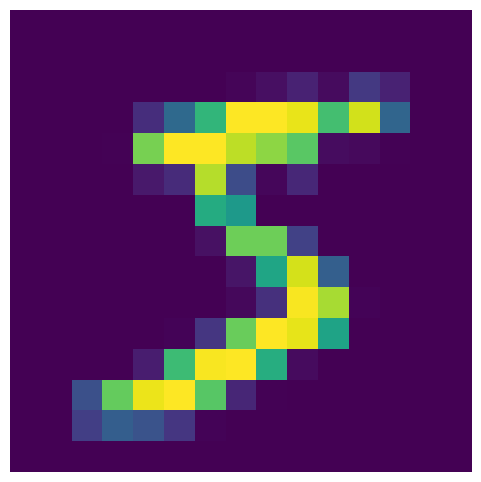

In [49]:
fig, ax = plt.subplots(figsize=(6, 6))

plt.imshow(cv2.resize(x_train[0,:,:], dsize=(15,15)))
plt.axis("off")

plt.savefig("images/img_example.png")

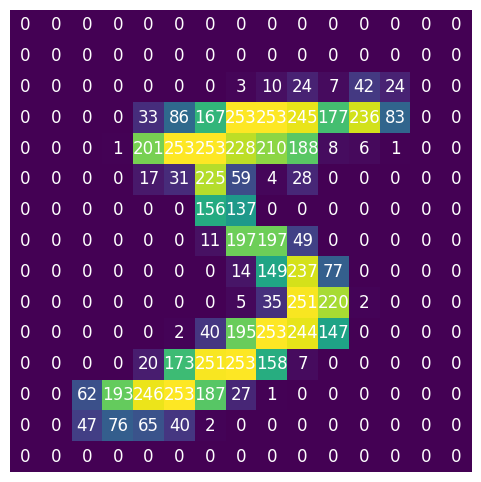

In [50]:
fig, ax = plt.subplots(figsize=(6, 6))

plt.imshow(cv2.resize(x_train[0,:,:], dsize=(15,15)))

plt.axis("off")

for i in range(cv2.resize(x_train[0,:,:], dsize=(15,15)).shape[0]):
    for j in range(cv2.resize(x_train[0,:,:], dsize=(15,15)).shape[1]):
        # The coordinates (j, i) place the text at the center of the cell
        # 'ha' and 'va' set horizontal and vertical alignment to the center
        text_label = cv2.resize(x_train[0,:,:], dsize=(15,15))[i, j]
        ax.text(j, i, text_label, ha='center', va='center', color='white', fontsize=12)

plt.savefig("images/img_data_structure_example.png")

In [41]:
cv2.resize(x_train[0,:,:], dsize=(10,10))

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,  12, 153, 216, 253, 187, 158,  22,   0],
       [  0,   0,   0, 102, 245,   1,  32,   0,   0,   0],
       [  0,   0,   0,   0, 182,  23,   0,   0,   0,   0],
       [  0,   0,   0,   0,   1, 180, 168,   0,   0,   0],
       [  0,   0,   0,   0,   0,  85, 252,  10,   0,   0],
       [  0,   0,   0,  59, 239, 228,  58,   0,   0,   0],
       [  0,  55, 243, 217,  85,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0]], dtype=uint8)

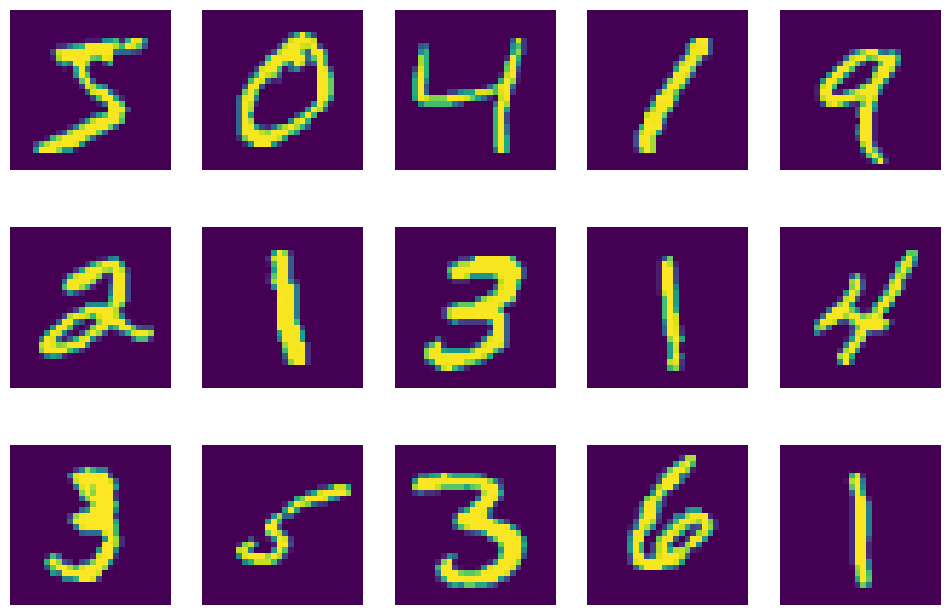

In [31]:
plt.figure(figsize=(12,8))

for i in range(15):

    plt.subplot(3,5,i+1)
    plt.imshow(x_train[i,:,:])
    plt.axis("off")

plt.savefig("images/img-data-viz.png")

In [3]:
x_train_reshape = np.reshape(x_train, (np.shape(x_train)[0], np.prod(np.shape(x_train)[1:])))
x_test_reshape = np.reshape(x_test, (np.shape(x_test)[0], np.prod(np.shape(x_test)[1:])))

In [8]:
pca = PCA(n_components=3).fit(x_test_reshape)

In [51]:
x_test_lower_dim_pca = pca.transform(x_test_reshape)

In [56]:
fig = go.Figure()

for index_aux in np.unique(y_test):

    indices_aux = np.where(y_test == index_aux)[0]

    fig.add_trace(
        go.Scatter3d(
            x=x_test_lower_dim_pca[indices_aux,0], 
            y=x_test_lower_dim_pca[indices_aux,1], 
            z=x_test_lower_dim_pca[indices_aux,2], 
            mode='markers',
            marker=dict(
                size=3,
            ), 
            name=str(index_aux)
        )
    )

fig.update_layout(title='PCA')
fig.show()

In [57]:
fig.write_html("images/pca-viz.html")

In [12]:
x_test_lower_dim_tsne = TSNE(n_components=3).fit_transform(x_test_reshape)

In [58]:
fig = go.Figure()

for index_aux in np.unique(y_test):

    indices_aux = np.where(y_test == index_aux)[0]

    fig.add_trace(
        go.Scatter3d(
            x=x_test_lower_dim_tsne[indices_aux,0], 
            y=x_test_lower_dim_tsne[indices_aux,1], 
            z=x_test_lower_dim_tsne[indices_aux,2], 
            mode='markers',
            marker=dict(
                size=3,
            ), 
            name=str(index_aux)
        )
    )

fig.update_layout(title='TSNE')
fig.show()

In [59]:
fig.write_html("images/tsne-viz.html")